In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

df = pd.read_csv('../data/processed/titanic_transformation.csv')
df.head()

,survived,pclass,fare,familySize,age,sex_male,embarked_Q,embarked_S
0,1,1,211.3375,0,29.00,0,0,1
1,1,1,151.5500,3,0.92,1,0,1
2,0,1,151.5500,3,2.00,0,0,1
3,0,1,151.5500,3,30.00,1,0,1
4,0,1,151.5500,3,25.00,0,0,1


**Separación de variables predictoras y objetivo**

In [7]:
X = df.drop('survived', axis=1)
X

,pclass,fare,familySize,age,sex_male,embarked_Q,embarked_S
0,1,211.3375,0,29.00,0,0,1
1,1,151.5500,3,0.92,1,0,1
2,1,151.5500,3,2.00,0,0,1
3,1,151.5500,3,30.00,1,0,1
4,1,151.5500,3,25.00,0,0,1
...,...,...,...,...,...,...,...
1304,3,14.4542,1,14.50,0,0,0
1305,3,14.4542,1,28.00,0,0,0
1306,3,7.2250,0,26.50,1,0,0
1307,3,7.2250,0,27.00,1,0,0


In [3]:
y = df['survived']
y

0       1
1       1
2       0
3       0
4       0
       ..
1304    0
1305    0
1306    0
1307    0
1308    0
Name: survived, Length: 1309, dtype: int64

**División en conjuntos de entrenamiento y prueba**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature importance utilizando todas las variables**

Importancia de cada variable predictora

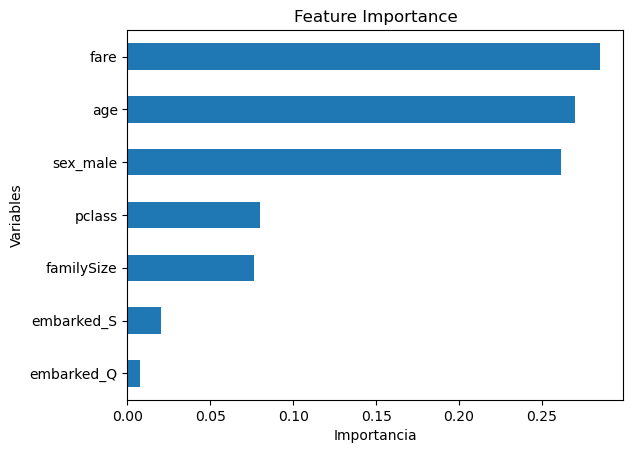

In [24]:
# Modelo
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# Obtener importancia
importances = model.feature_importances_

# Convertir a DataFrame
feat_importances = pd.Series(importances, index=X.columns)

# Ordenar
feat_importances = feat_importances.sort_values(ascending=True)

# Graficar
plt.figure()
feat_importances.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.show()

Con base en la gráfica, las variables que explican las decisiones del modelo en un porcentaje relativamente alto son 'fare, age, sex_male'. Lo cual comprueba que aunque el histograma con grupos de edades mostraba que no había una aparente diferencia entre cada grupo en la proporción de sobrevivientes, la edad por sí sola no explica en totalidad la supervivencia, pero en combinación con otras sí lo hace

## **Probar modelo eliminando variables**

Se crea una función con el fin de reutilizar código para hacer eliminación de variables experimental e ir capturando las métricas del modelo con cada selección hasta llegar a la combinación más óptima de variables predictoras 

In [ ]:

def evaluar_modelo(features, X_train, X_test, y_train, y_test):
    
    # Seleccionar variables
    X_train_sel = X_train[features]
    X_test_sel = X_test[features]
    
    # Modelo
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_sel, y_train)
    
    # Predicción
    y_pred = model.predict(X_test_sel)
    
    # Métrica
    f1 = f1_score(y_test, y_pred)
    
    return f1

**Métricas**

In [33]:
resultados = []

listas_features = {
    "1": ['sex_male', 'pclass', 'fare','familySize','age','embarked_S','embarked_Q'],
    "2": ['sex_male', 'pclass', 'fare','familySize','age'],
    "3": ['sex_male', 'fare','familySize','age'],
    "4": ['sex_male', 'fare','age'],
}

for nombre, features in listas_features.items():
    f1 = evaluar_modelo(features, X_train, X_test, y_train, y_test)
    
    resultados.append({
        "features": features,
        "f1_score": f1
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

                                            features  f1_score
0  [sex_male, pclass, fare, familySize, age, emba...  0.752294
1          [sex_male, pclass, fare, familySize, age]  0.714976
2                  [sex_male, fare, familySize, age]  0.734884
3                              [sex_male, fare, age]  0.731481


Dado que no existe un costo real asociado a FP o FN en este dataset, se prioriza F1-score como balance entre precision y recall.

Se evaluaron distintas combinaciones de variables, encontrando que el modelo con todas las features obtuvo el mejor desempeño (F1 = 0.752). Sin embargo, modelos más simples mostraron resultados comparables, lo que sugiere que algunas variables aportan valor marginal pero no crítico. 
En conclusión, se selecciona el modelo con las variables 'sex_male, fare, age' ya que contiene menos predictoras y su rendimiento varía en un 0.02 en comparación con el modelo más complejo que considera a todas las variables